# Exploratory Data Analysis — Cement Demand Forecasting

In [2]:
from pathlib import Path

# Import pandas for data loading and analysis.
import pandas as pd

# Import NumPy for numerical operations.
import numpy as np

# Import Matplotlib for creating charts and visualisations.
import matplotlib.pyplot as plt

# Confirm that the libraries were imported successfully.
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Build the path to the processed-data folder.
# Path.cwd() gives the current notebook folder.
# .parent moves one level up to the project root.
processed_directory = (
    Path.cwd().parent
    / "data"
    / "processed"
)

# Build the full path to the final merged Parquet dataset.
data_path = (
    processed_directory
    / "cement_operations_merged.parquet"
)

# Load the final cleaned and merged dataset into a pandas DataFrame.
df = pd.read_parquet(data_path)

# Display the number of rows and columns in the dataset.
print("Dataset shape:", df.shape)

# Display the first five rows to confirm the data loaded correctly.
df.head()

Dataset shape: (32880, 20)


,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,opening_over_capacity_flag,closing_over_capacity_flag,available_inventory_tonnes,consumption_over_available_flag,unmet_demand_tonnes,stockout_flag,pour_fulfilment_rate,region,behavior
0,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,0,0,83.82,0,0.00,0,1.0000,North,aggressive
1,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,0,0,65.80,0,0.00,0,1.0000,North,aggressive
2,2022-01-07,SITE_001,CEM_I,33.60,33.60,0.00,47.72,14.12,0.90,4.48,448,0,0,47.72,0,0.00,0,1.0000,North,aggressive
3,2022-01-08,SITE_001,CEM_I,42.12,34.28,14.12,20.16,0.00,1.95,25.92,448,0,0,34.28,0,7.84,1,0.8139,North,aggressive
4,2022-01-09,SITE_001,CEM_I,0.00,0.00,0.00,34.38,34.38,1.42,16.81,448,0,0,34.38,0,0.00,0,NaN,North,aggressive


## 2. Dataset Overview

This section examines the structure of the final dataset, including its
dimensions, data types, date coverage, unique sites, cement types, regions,
and site behaviour categories.

In [4]:
# Display the structure of the dataset.
# This shows column names, data types, non-null counts and memory usage.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32880 entries, 0 to 32879
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             32880 non-null  datetime64[us]
 1   site_id                          32880 non-null  string        
 2   cement_type                      32880 non-null  string        
 3   planned_pour_tonnes              32880 non-null  float64       
 4   consumed_tonnes                  32880 non-null  float64       
 5   opening_inventory_tonnes         32880 non-null  float64       
 6   deliveries_tonnes                32880 non-null  float64       
 7   closing_inventory_tonnes         32880 non-null  float64       
 8   rain_mm                          32880 non-null  float64       
 9   avg_temp_c                       32880 non-null  float64       
 10  silo_capacity                    32880 non-null  int64         
 11  

In [5]:
# Display the overall dimensions of the dataset.
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display the period covered by the dataset.
print("\nStart date:", df["date"].min())
print("End date:", df["date"].max())

# Count the number of unique construction sites.
print("\nNumber of sites:", df["site_id"].nunique())

# Count the number of different cement types.
print("Number of cement types:", df["cement_type"].nunique())

# Count the number of geographical regions.
print("Number of regions:", df["region"].nunique())

# Count the number of site behaviour categories.
print("Number of behaviour categories:", df["behavior"].nunique())

Number of rows: 32880
Number of columns: 20

Start date: 2022-01-01 00:00:00
End date: 2024-12-31 00:00:00

Number of sites: 30
Number of cement types: 3
Number of regions: 4
Number of behaviour categories: 3


In [6]:
# Display the unique cement types in the dataset.
print("Cement types:")
print(df["cement_type"].unique())

# Display the unique geographical regions.
print("\nRegions:")
print(df["region"].unique())

# Display the unique site behaviour categories.
print("\nBehaviour categories:")
print(df["behavior"].unique())

Cement types:
<ArrowStringArray>
['CEM_I', 'CEM_II', 'CEM_III']
Length: 3, dtype: string

Regions:
<ArrowStringArray>
['North', 'South', 'East', 'West']
Length: 4, dtype: string

Behaviour categories:
<ArrowStringArray>
['aggressive', 'conservative', 'chaotic']
Length: 3, dtype: string


In [7]:
# Count the number of observations for each cement type.
print("Records by cement type:")
print(df["cement_type"].value_counts())

# Count the number of observations for each geographical region.
print("\nRecords by region:")
print(df["region"].value_counts())

# Count the number of observations for each site behaviour category.
print("\nRecords by behaviour:")
print(df["behavior"].value_counts())

Records by cement type:
cement_type
CEM_II     11097
CEM_I      10913
CEM_III    10870
Name: count, dtype: int64[pyarrow]

Records by region:
region
East     13152
South    12056
West      4384
North     3288
Name: count, dtype: int64[pyarrow]

Records by behaviour:
behavior
aggressive      15344
conservative     9864
chaotic          7672
Name: count, dtype: int64[pyarrow]


In [8]:
# Count the number of unique sites in each region.
sites_by_region = (
    df.groupby("region")["site_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Number of sites by region:")
print(sites_by_region)


# Count the number of unique sites in each behaviour category.
sites_by_behaviour = (
    df.groupby("behavior")["site_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nNumber of sites by behaviour:")
print(sites_by_behaviour)

Number of sites by region:
region
East     12
South    11
West      4
North     3
Name: site_id, dtype: int64

Number of sites by behaviour:
behavior
aggressive      14
conservative     9
chaotic          7
Name: site_id, dtype: int64


## 3. Numerical Descriptive Statistics

This section examines the central tendency, variability and range of the
numerical variables. The analysis helps identify demand patterns, inventory
levels, delivery behaviour, weather conditions and potentially unusual
observations that may require further investigation.

In [9]:
# Select the main continuous numerical variables for exploratory analysis.
numerical_columns = [
    "planned_pour_tonnes",
    "consumed_tonnes",
    "opening_inventory_tonnes",
    "deliveries_tonnes",
    "closing_inventory_tonnes",
    "rain_mm",
    "avg_temp_c",
    "silo_capacity",
    "available_inventory_tonnes",
    "unmet_demand_tonnes",
    "pour_fulfilment_rate"
]

# Generate descriptive statistics for the selected numerical variables.
# This includes count, mean, standard deviation, minimum,
# quartiles (25%, 50%, 75%) and maximum.
descriptive_statistics = df[numerical_columns].describe().T

# Display the statistics rounded to two decimal places
# to make the table easier to interpret.
descriptive_statistics.round(2)

,count,mean,std,min,25%,50%,75%,max
planned_pour_tonnes,32880.0,30.70,19.49,0.0,12.83,33.46,47.61,69.98
consumed_tonnes,32880.0,23.72,16.85,0.0,10.71,19.72,36.49,69.97
opening_inventory_tonnes,32880.0,3066.68,5586.03,0.0,1.28,50.71,3298.52,20646.18
deliveries_tonnes,32880.0,29.29,12.33,0.0,19.30,29.49,39.75,50.00
closing_inventory_tonnes,32880.0,3072.25,5593.02,0.0,1.27,50.66,3312.06,20658.87
rain_mm,32880.0,5.01,5.00,0.0,1.44,3.47,6.97,50.00
avg_temp_c,32880.0,10.09,8.52,-5.0,3.34,9.99,16.70,35.00
silo_capacity,32880.0,317.53,112.81,120.0,230.00,314.00,437.00,487.00
available_inventory_tonnes,32880.0,3095.98,5586.40,0.0,38.30,81.94,3328.76,20670.67
unmet_demand_tonnes,32880.0,6.98,12.28,0.0,0.00,0.00,9.49,69.62


## 4. Inventory and Silo Capacity Investigation

The descriptive statistics show substantial differences between reported
inventory levels and silo capacity. This section investigates the magnitude
and distribution of these observations to determine whether they represent
specific sites, operational patterns or potential anomalies requiring
consideration before modelling.

In [10]:
# Count observations where opening inventory exceeds silo capacity.
opening_over_capacity = (
    df["opening_inventory_tonnes"] > df["silo_capacity"]
)

# Count observations where closing inventory exceeds silo capacity.
closing_over_capacity = (
    df["closing_inventory_tonnes"] > df["silo_capacity"]
)

# Display the number and percentage of affected observations.
print(
    "Opening inventory over capacity:",
    opening_over_capacity.sum(),
    f"({opening_over_capacity.mean() * 100:.2f}%)"
)

print(
    "Closing inventory over capacity:",
    closing_over_capacity.sum(),
    f"({closing_over_capacity.mean() * 100:.2f}%)"
)

Opening inventory over capacity: 11427 (34.75%)
Closing inventory over capacity: 11439 (34.79%)


In [11]:
# Calculate the maximum reported inventory and silo capacity for each site.
site_inventory_check = (
    df.groupby("site_id")
    .agg(
        max_opening_inventory=("opening_inventory_tonnes", "max"),
        max_closing_inventory=("closing_inventory_tonnes", "max"),
        silo_capacity=("silo_capacity", "max")
    )
)

# Calculate how many times larger the maximum inventory is
# compared with the site's stated silo capacity.
site_inventory_check["opening_capacity_ratio"] = (
    site_inventory_check["max_opening_inventory"]
    / site_inventory_check["silo_capacity"]
)

site_inventory_check["closing_capacity_ratio"] = (
    site_inventory_check["max_closing_inventory"]
    / site_inventory_check["silo_capacity"]
)

# Display sites with the largest opening-inventory-to-capacity ratios.
site_inventory_check.sort_values(
    "opening_capacity_ratio",
    ascending=False
).head(10).round(2)

,max_opening_inventory,max_closing_inventory,silo_capacity,opening_capacity_ratio,closing_capacity_ratio
site_id,,,,,
SITE_015,20631.10,20658.87,120,171.93,172.16
SITE_023,19198.47,19208.45,153,125.48,125.55
SITE_012,20456.03,20476.64,274,74.66,74.73
SITE_002,19960.22,19963.37,288,69.31,69.32
SITE_027,20000.39,20022.30,314,63.70,63.77
SITE_009,20249.99,20285.40,352,57.53,57.63
SITE_029,20456.53,20472.10,437,46.81,46.85
SITE_019,20646.18,20648.91,466,44.31,44.31
SITE_004,20500.79,20505.34,472,43.43,43.44


In [12]:
# Identify records where opening inventory exceeds silo capacity.
opening_over_capacity = (
    df["opening_inventory_tonnes"] > df["silo_capacity"]
)

# Identify records where closing inventory exceeds silo capacity.
closing_over_capacity = (
    df["closing_inventory_tonnes"] > df["silo_capacity"]
)

# Display counts and percentages.
print(
    "Opening inventory over capacity:",
    opening_over_capacity.sum(),
    f"({opening_over_capacity.mean() * 100:.2f}%)"
)

print(
    "Closing inventory over capacity:",
    closing_over_capacity.sum(),
    f"({closing_over_capacity.mean() * 100:.2f}%)"
)

Opening inventory over capacity: 11427 (34.75%)
Closing inventory over capacity: 11439 (34.79%)


In [13]:
# Calculate the percentage of records exceeding capacity for each site.
capacity_issues_by_site = (
    df.assign(
        opening_over_capacity=opening_over_capacity,
        closing_over_capacity=closing_over_capacity
    )
    .groupby("site_id")
    .agg(
        total_records=("site_id", "size"),
        opening_over_capacity=("opening_over_capacity", "sum"),
        closing_over_capacity=("closing_over_capacity", "sum")
    )
)

# Convert the counts into percentages.
capacity_issues_by_site["opening_over_capacity_pct"] = (
    capacity_issues_by_site["opening_over_capacity"]
    / capacity_issues_by_site["total_records"]
    * 100
)

capacity_issues_by_site["closing_over_capacity_pct"] = (
    capacity_issues_by_site["closing_over_capacity"]
    / capacity_issues_by_site["total_records"]
    * 100
)

# Display the sites with the highest proportion of capacity violations.
capacity_issues_by_site.sort_values(
    "opening_over_capacity_pct",
    ascending=False
).head(15).round(2)

,total_records,opening_over_capacity,closing_over_capacity,opening_over_capacity_pct,closing_over_capacity_pct
site_id,,,,,
SITE_015,1096,1090,1091,99.45,99.54
SITE_012,1096,1085,1086,99.0,99.09
SITE_023,1096,1084,1085,98.91,99.0
SITE_002,1096,1082,1083,98.72,98.81
SITE_009,1096,1082,1083,98.72,98.81
SITE_027,1096,1081,1082,98.63,98.72
SITE_029,1096,1076,1077,98.18,98.27
SITE_004,1096,1074,1075,97.99,98.08
SITE_019,1096,1074,1075,97.99,98.08


### Inventory Capacity Observation

The analysis identified substantial differences between reported inventory
levels and stated silo capacities across several sites. The issue is systematic
rather than limited to isolated observations.

For example, SITE_015 recorded opening inventory above its stated silo capacity
in approximately 99.45% of observations. Several other sites, including
SITE_012, SITE_023, SITE_002 and SITE_009, also exceeded their stated capacities
in approximately 98–99% of records.

The persistence of this pattern suggests that these observations should not
automatically be treated as random outliers. They may reflect differences in
the definition or measurement of inventory and silo capacity, site-specific
operational characteristics, or an underlying data issue.

The records are therefore retained during exploratory analysis, while the
potential impact of inventory-related variables on subsequent feature
engineering and forecasting will be considered carefully.

## 5. Cement Demand Analysis

This section explores the distribution of planned cement demand and actual
cement consumption. The analysis examines typical demand levels, variability,
zero-demand periods and differences between planned and consumed quantities.

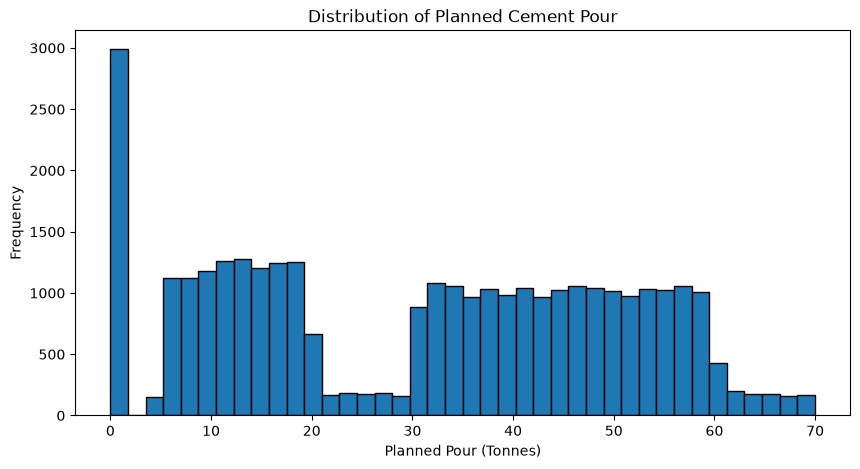

In [14]:
# Create a histogram showing the distribution of planned cement demand.
plt.figure(figsize=(10, 5))

plt.hist(
    df["planned_pour_tonnes"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Planned Cement Pour")
plt.xlabel("Planned Pour (Tonnes)")
plt.ylabel("Frequency")

plt.show()

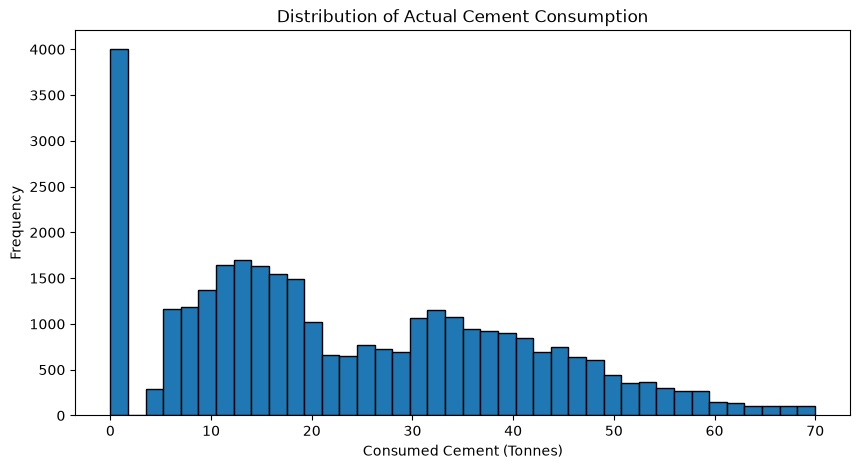

In [15]:
# Create a histogram showing the distribution of actual cement consumption.
plt.figure(figsize=(10, 5))

plt.hist(
    df["consumed_tonnes"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Actual Cement Consumption")
plt.xlabel("Consumed Cement (Tonnes)")
plt.ylabel("Frequency")

plt.show()

In [16]:
# Count observations where no cement pour was planned.
zero_planned = (df["planned_pour_tonnes"] == 0).sum()

# Count observations where no cement was consumed.
zero_consumed = (df["consumed_tonnes"] == 0).sum()

# Calculate their percentages.
zero_planned_pct = zero_planned / len(df) * 100
zero_consumed_pct = zero_consumed / len(df) * 100

print(
    f"Zero planned pour: {zero_planned} "
    f"({zero_planned_pct:.2f}%)"
)

print(
    f"Zero consumption: {zero_consumed} "
    f"({zero_consumed_pct:.2f}%)"
)

Zero planned pour: 2993 (9.10%)
Zero consumption: 4003 (12.17%)


In [17]:
# Count observations where no cement pour was planned.
zero_planned = (df["planned_pour_tonnes"] == 0).sum()

# Count observations where no cement was consumed.
zero_consumed = (df["consumed_tonnes"] == 0).sum()

# Calculate the percentage of observations with zero planned pour.
zero_planned_pct = zero_planned / len(df) * 100

# Calculate the percentage of observations with zero actual consumption.
zero_consumed_pct = zero_consumed / len(df) * 100

# Display the number and percentage of zero planned-pour observations.
print(
    f"Zero planned pour: {zero_planned} "
    f"({zero_planned_pct:.2f}%)"
)

# Display the number and percentage of zero-consumption observations.
print(
    f"Zero consumption: {zero_consumed} "
    f"({zero_consumed_pct:.2f}%)"
)

Zero planned pour: 2993 (9.10%)
Zero consumption: 4003 (12.17%)


### Zero-Demand Observations

Approximately 9.10% of observations have zero planned cement pour, while
12.17% have zero actual cement consumption. The higher proportion of zero
consumption indicates that some observations had planned demand but no actual
cement consumption.

These zero-demand periods are important for forecasting because they indicate
that cement demand is intermittent to some extent and that actual consumption
does not always follow planned demand.

In [18]:
# Identify observations where cement was planned
# but no cement was actually consumed.
planned_but_not_consumed = (
    (df["planned_pour_tonnes"] > 0)
    & (df["consumed_tonnes"] == 0)
)

# Count these observations.
planned_but_not_consumed_count = planned_but_not_consumed.sum()

# Calculate their percentage of the complete dataset.
planned_but_not_consumed_pct = (
    planned_but_not_consumed_count / len(df) * 100
)

# Display the results.
print(
    f"Planned pour but zero consumption: "
    f"{planned_but_not_consumed_count} "
    f"({planned_but_not_consumed_pct:.2f}%)"
)

Planned pour but zero consumption: 1010 (3.07%)


In [19]:
# Identify observations where there was no planned pour
# but cement was nevertheless consumed.
unplanned_consumption = (
    (df["planned_pour_tonnes"] == 0)
    & (df["consumed_tonnes"] > 0)
)

# Count these observations.
unplanned_consumption_count = unplanned_consumption.sum()

# Calculate their percentage.
unplanned_consumption_pct = (
    unplanned_consumption_count / len(df) * 100
)

# Display the results.
print(
    f"Zero planned pour but positive consumption: "
    f"{unplanned_consumption_count} "
    f"({unplanned_consumption_pct:.2f}%)"
)

Zero planned pour but positive consumption: 0 (0.00%)


## 6. Temporal Demand Analysis

This section examines how planned cement demand and actual cement consumption
change over time. Monthly aggregation is used to identify broader trends,
seasonality and differences between planned and actual demand.

In [20]:
# Create a monthly period from the date column.
# This allows daily observations to be aggregated into monthly totals.
df["month"] = df["date"].dt.to_period("M")

# Calculate total planned pour and actual consumption for each month.
monthly_demand = (
    df.groupby("month")
    .agg(
        planned_pour_tonnes=("planned_pour_tonnes", "sum"),
        consumed_tonnes=("consumed_tonnes", "sum")
    )
    .reset_index()
)

# Convert the monthly period back to a timestamp
# so that Matplotlib can display it correctly on the x-axis.
monthly_demand["month"] = monthly_demand["month"].dt.to_timestamp()

# Display the first few monthly observations.
monthly_demand.head()

,month,planned_pour_tonnes,consumed_tonnes
0,2022-01-01,28687.29,23081.34
1,2022-02-01,25216.88,19741.34
2,2022-03-01,29144.90,22562.45
3,2022-04-01,28289.76,21723.16
4,2022-05-01,28308.24,21475.18


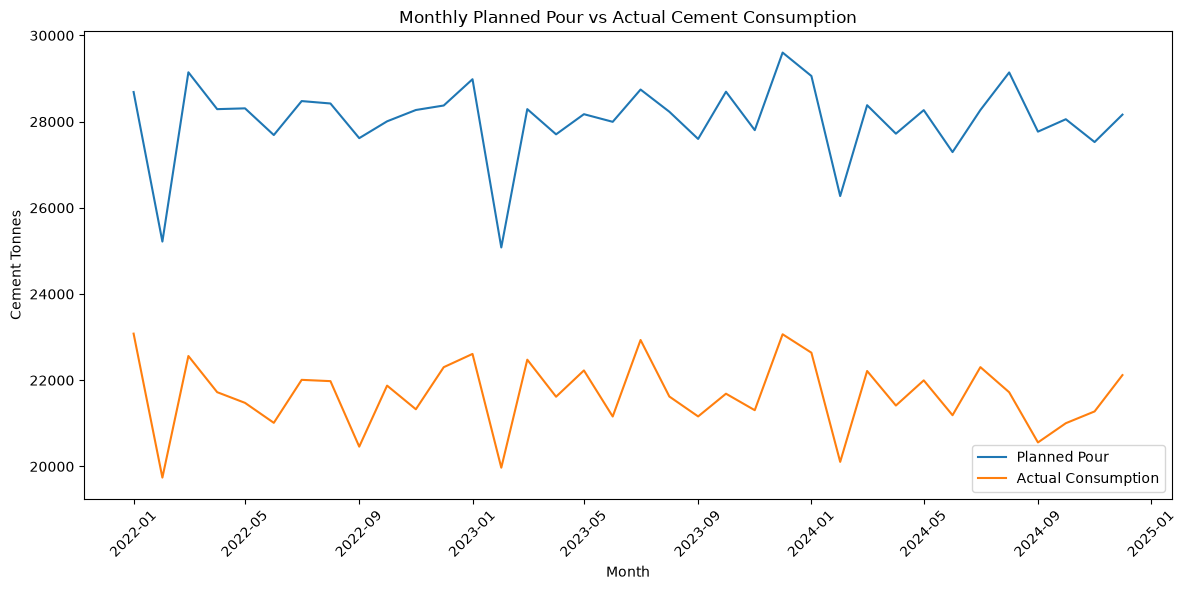

In [21]:
# Create a line chart comparing monthly planned demand
# with monthly actual cement consumption.
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_demand["month"],
    monthly_demand["planned_pour_tonnes"],
    label="Planned Pour"
)

plt.plot(
    monthly_demand["month"],
    monthly_demand["consumed_tonnes"],
    label="Actual Consumption"
)

# Add descriptive chart labels.
plt.title("Monthly Planned Pour vs Actual Cement Consumption")
plt.xlabel("Month")
plt.ylabel("Cement Tonnes")

# Display the series labels.
plt.legend()

# Improve the readability of the chart.
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [22]:
# Calculate the difference between planned demand
# and actual cement consumption for each month.
monthly_demand["demand_gap_tonnes"] = (
    monthly_demand["planned_pour_tonnes"]
    - monthly_demand["consumed_tonnes"]
)

# Display summary statistics for the monthly demand gap.
monthly_demand["demand_gap_tonnes"].describe().round(2)

count      36.00
mean     6372.04
std       501.85
min      5109.27
25%      6083.92
50%      6396.57
75%      6624.92
max      7419.70
Name: demand_gap_tonnes, dtype: float64

### Monthly Demand Gap

Across the 36-month study period, the average monthly difference between
planned cement pour and actual consumption was approximately 6,372 tonnes.
The median monthly gap was approximately 6,397 tonnes, which is close to the
mean and indicates that the aggregate monthly gap is relatively consistent.

Monthly demand gaps ranged from approximately 5,109 tonnes to 7,420 tonnes,
with a standard deviation of approximately 502 tonnes. This indicates a
persistent difference between planned cement requirements and actual
consumption throughout the study period.

Further analysis is required to determine whether this gap varies systematically
by season, cement type, site, region or operational behaviour.

In [23]:
# Extract the calendar month from the date column.
# Month numbers range from 1 (January) to 12 (December).
df["month_number"] = df["date"].dt.month

# Calculate average daily planned pour and actual consumption
# for each calendar month across the three-year period.
seasonal_demand = (
    df.groupby("month_number")
    .agg(
        avg_planned_pour=("planned_pour_tonnes", "mean"),
        avg_consumption=("consumed_tonnes", "mean")
    )
    .reset_index()
)

# Add readable month names to make the results easier to interpret.
seasonal_demand["month"] = pd.to_datetime(
    seasonal_demand["month_number"],
    format="%m"
).dt.month_name()

# Display the results.
seasonal_demand.round(2)

,month_number,avg_planned_pour,avg_consumption,month
0,1,31.09,24.49,January
1,2,30.03,23.46,February
2,3,30.76,24.11,March
3,4,31.01,23.98,April
4,5,30.38,23.55,May
5,6,30.73,23.47,June
6,7,30.64,24.10,July
7,8,30.75,23.41,August
8,9,30.73,23.03,September
9,10,30.38,23.14,October


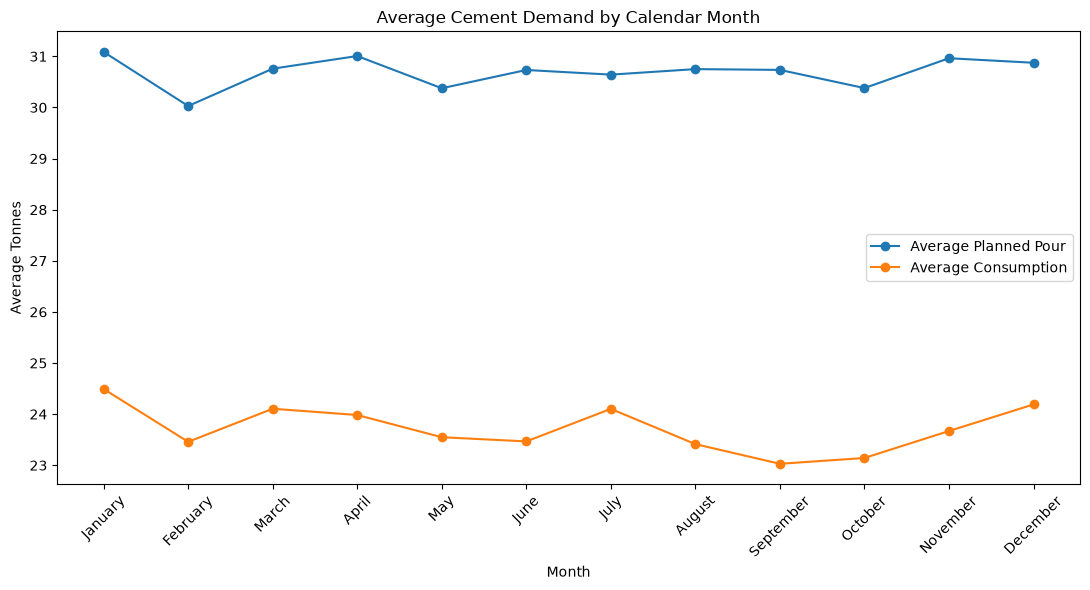

In [24]:
# Create a line chart showing average demand by calendar month.
plt.figure(figsize=(11, 6))

plt.plot(
    seasonal_demand["month"],
    seasonal_demand["avg_planned_pour"],
    marker="o",
    label="Average Planned Pour"
)

plt.plot(
    seasonal_demand["month"],
    seasonal_demand["avg_consumption"],
    marker="o",
    label="Average Consumption"
)

# Add chart title and axis labels.
plt.title("Average Cement Demand by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average Tonnes")

# Rotate month names for readability.
plt.xticks(rotation=45)

# Display the legend and improve spacing.
plt.legend()
plt.tight_layout()

plt.show()

In [27]:
# Calculate average planned pour, consumption and unmet demand
# for each cement type.
demand_by_cement = (
    df.groupby("cement_type")
    .agg(
        avg_planned_pour=("planned_pour_tonnes", "mean"),
        avg_consumption=("consumed_tonnes", "mean"),
        avg_unmet_demand=("unmet_demand_tonnes", "mean"),
        total_consumption=("consumed_tonnes", "sum")
    )
    .round(2)
)

# Display the results.
demand_by_cement

,avg_planned_pour,avg_consumption,avg_unmet_demand,total_consumption
cement_type,,,,
CEM_I,30.96,23.82,7.14,259954.71
CEM_II,30.60,23.74,6.86,263418.26
CEM_III,30.53,23.60,6.93,256556.24


In [28]:
# Compare demand performance across geographical regions.
demand_by_region = (
    df.groupby("region")
    .agg(
        number_of_sites=("site_id", "nunique"),
        avg_planned_pour=("planned_pour_tonnes", "mean"),
        avg_consumption=("consumed_tonnes", "mean"),
        avg_unmet_demand=("unmet_demand_tonnes", "mean"),
        stockout_rate=("stockout_flag", "mean")
    )
)

# Convert the stockout rate to a percentage.
demand_by_region["stockout_rate"] *= 100

# Display rounded results.
demand_by_region.round(2)

,number_of_sites,avg_planned_pour,avg_consumption,avg_unmet_demand,stockout_rate
region,,,,,
East,12,31.04,24.25,6.79,22.51
North,3,21.97,17.59,4.38,15.51
South,11,32.24,24.46,7.78,27.77
West,4,31.98,24.69,7.30,25.82


In [29]:
# Compare operational performance across site behaviour categories.
demand_by_behaviour = (
    df.groupby("behavior")
    .agg(
        number_of_sites=("site_id", "nunique"),
        avg_planned_pour=("planned_pour_tonnes", "mean"),
        avg_consumption=("consumed_tonnes", "mean"),
        avg_unmet_demand=("unmet_demand_tonnes", "mean"),
        stockout_rate=("stockout_flag", "mean"),
        avg_fulfilment_rate=("pour_fulfilment_rate", "mean")
    )
)

# Convert rates to percentages for easier interpretation.
demand_by_behaviour["stockout_rate"] *= 100
demand_by_behaviour["avg_fulfilment_rate"] *= 100

demand_by_behaviour.round(2)

,number_of_sites,avg_planned_pour,avg_consumption,avg_unmet_demand,stockout_rate,avg_fulfilment_rate
behavior,,,,,,
aggressive,14,42.74,30.01,12.73,47.65,71.58
chaotic,7,30.82,26.82,3.99,8.33,88.56
conservative,9,11.88,11.52,0.35,0.00,97.01


### Demand and Operational Performance by Site Behaviour

Clear differences in demand and operational performance were observed across
the three site behaviour categories.

Aggressive sites recorded the highest average planned pour at 42.74 tonnes,
compared with average consumption of 30.01 tonnes. These sites also experienced
the highest average unmet demand at 12.73 tonnes, a stockout rate of 47.65%,
and the lowest average fulfilment rate at 71.58%.

Chaotic sites showed moderate planned demand of 30.82 tonnes and average
consumption of 26.82 tonnes. Their average unmet demand was 3.99 tonnes,
with an 8.33% stockout rate and an average fulfilment rate of 88.56%.

Conservative sites recorded the lowest planned demand at 11.88 tonnes, but
actual consumption was close to planned demand at 11.52 tonnes. They had
only 0.35 tonnes of average unmet demand, no recorded stockouts, and the
highest average fulfilment rate at 97.01%.

These results indicate a strong association between site behaviour and
operational demand performance. Behaviour category may therefore provide
useful information during subsequent feature engineering and forecasting.

In [30]:
# Calculate the overall number of stockout observations.
stockout_count = df["stockout_flag"].sum()

# Calculate the overall stockout rate as a percentage.
stockout_rate = df["stockout_flag"].mean() * 100

# Display the overall results.
print(f"Number of stockouts: {stockout_count}")
print(f"Overall stockout rate: {stockout_rate:.2f}%")

Number of stockouts: 7950
Overall stockout rate: 24.18%


In [31]:
# Calculate stockout performance for each site.
stockout_by_site = (
    df.groupby("site_id")
    .agg(
        total_records=("site_id", "size"),
        stockouts=("stockout_flag", "sum"),
        avg_planned_pour=("planned_pour_tonnes", "mean"),
        avg_unmet_demand=("unmet_demand_tonnes", "mean")
    )
)

# Calculate each site's stockout percentage.
stockout_by_site["stockout_rate"] = (
    stockout_by_site["stockouts"]
    / stockout_by_site["total_records"]
    * 100
)

# Display sites with the highest stockout rates.
stockout_by_site.sort_values(
    "stockout_rate",
    ascending=False
).head(10).round(2)

,total_records,stockouts,avg_planned_pour,avg_unmet_demand,stockout_rate
site_id,,,,,
SITE_022,1096,563,43.20,13.16,51.37
SITE_008,1096,547,43.01,13.19,49.91
SITE_011,1096,546,43.29,13.56,49.82
SITE_021,1096,535,43.22,13.10,48.81
SITE_020,1096,531,42.52,12.79,48.45
SITE_017,1096,525,42.59,12.91,47.9
SITE_010,1096,518,42.81,12.17,47.26
SITE_005,1096,516,42.32,12.26,47.08
SITE_025,1096,515,42.72,12.05,46.99


### Site-Level Stockout Analysis

The site-level analysis indicates that high stockout rates are distributed
across multiple sites rather than being driven by a single problematic site.

Among the sites with the highest stockout rates, approximately 46% to 51% of
observations were associated with stockouts. SITE_022 recorded the highest
stockout rate at 51.37%, followed by SITE_008 at 49.91% and SITE_011 at 49.82%.

These high-stockout sites also showed similar demand characteristics, with
average planned pours of approximately 42–43 tonnes and average unmet demand
of approximately 12–14 tonnes.

The consistency of these results suggests that stockout risk is associated
with a broader operational pattern affecting several high-demand sites rather
than an isolated site-specific issue. Further analysis of inventory,
deliveries and site behaviour may help explain these differences.

In [32]:
# Add each site's behaviour category to the stockout analysis.
stockout_by_site_with_behavior = (
    stockout_by_site
    .reset_index()
    .merge(
        df[["site_id", "behavior"]].drop_duplicates(),
        on="site_id",
        how="left"
    )
)

# Display the ten sites with the highest stockout rates,
# including their behaviour classification.
stockout_by_site_with_behavior.sort_values(
    "stockout_rate",
    ascending=False
).head(10).round(2)

,site_id,total_records,stockouts,avg_planned_pour,avg_unmet_demand,stockout_rate,behavior
21,SITE_022,1096,563,43.20,13.16,51.37,aggressive
7,SITE_008,1096,547,43.01,13.19,49.91,aggressive
10,SITE_011,1096,546,43.29,13.56,49.82,aggressive
20,SITE_021,1096,535,43.22,13.10,48.81,aggressive
19,SITE_020,1096,531,42.52,12.79,48.45,aggressive
16,SITE_017,1096,525,42.59,12.91,47.9,aggressive
9,SITE_010,1096,518,42.81,12.17,47.26,aggressive
4,SITE_005,1096,516,42.32,12.26,47.08,aggressive
24,SITE_025,1096,515,42.72,12.05,46.99,aggressive
0,SITE_001,1096,510,42.58,12.42,46.53,aggressive


### Stockouts and Site Behaviour

All ten sites with the highest stockout rates were classified as aggressive.
Their stockout rates ranged from approximately 46.53% to 51.37%, while their
average planned cement demand was consistently around 42–43 tonnes.

This finding supports the earlier behaviour-level analysis, where aggressive
sites showed substantially higher stockout rates, unmet demand and lower
fulfilment rates than chaotic and conservative sites.

The consistency of the pattern across several aggressive sites suggests that
the relationship is systematic rather than being driven by a single site.
However, the analysis demonstrates association rather than causation.
Inventory availability, delivery patterns, demand intensity and other
operational factors should also be investigated.

In [33]:
# Select weather and demand variables for correlation analysis.
weather_demand_columns = [
    "rain_mm",
    "avg_temp_c",
    "planned_pour_tonnes",
    "consumed_tonnes"
]

# Calculate Pearson correlations between the selected variables.
weather_demand_correlation = (
    df[weather_demand_columns]
    .corr()
    .round(3)
)

# Display the correlation matrix.
weather_demand_correlation

,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes
rain_mm,1.000,0.011,0.001,-0.180
avg_temp_c,0.011,1.000,0.003,0.035
planned_pour_tonnes,0.001,0.003,1.000,0.781
consumed_tonnes,-0.180,0.035,0.781,1.000


### Weather and Cement Demand

Correlation analysis identified a strong positive relationship between planned
cement pour and actual cement consumption (r = 0.781), indicating that higher
planned requirements are generally associated with higher actual consumption.

Rainfall showed almost no linear relationship with planned pour (r = 0.001)
but had a weak negative relationship with actual consumption (r = -0.180).
This suggests that rainfall does not materially influence planned demand but
may be associated with lower actual cement consumption.

Average temperature showed negligible linear relationships with both planned
pour (r = 0.003) and actual consumption (r = 0.035).

These results suggest that rainfall may provide some predictive information
for actual consumption, while temperature appears less informative when
considered independently. These relationships represent associations and
should not be interpreted as evidence of causation.

### Monthly Demand Pattern

Average planned pour and actual cement consumption remained relatively stable
across calendar months. Average planned demand ranged from approximately
30.03 to 31.09 tonnes, while average consumption ranged from approximately
23.03 to 24.49 tonnes.

The relatively narrow variation suggests that strong annual seasonality is
not immediately evident when demand is aggregated across all sites and cement
types. However, site-level or cement-type-specific seasonal patterns may still
exist and should be investigated before drawing final conclusions about
seasonality.

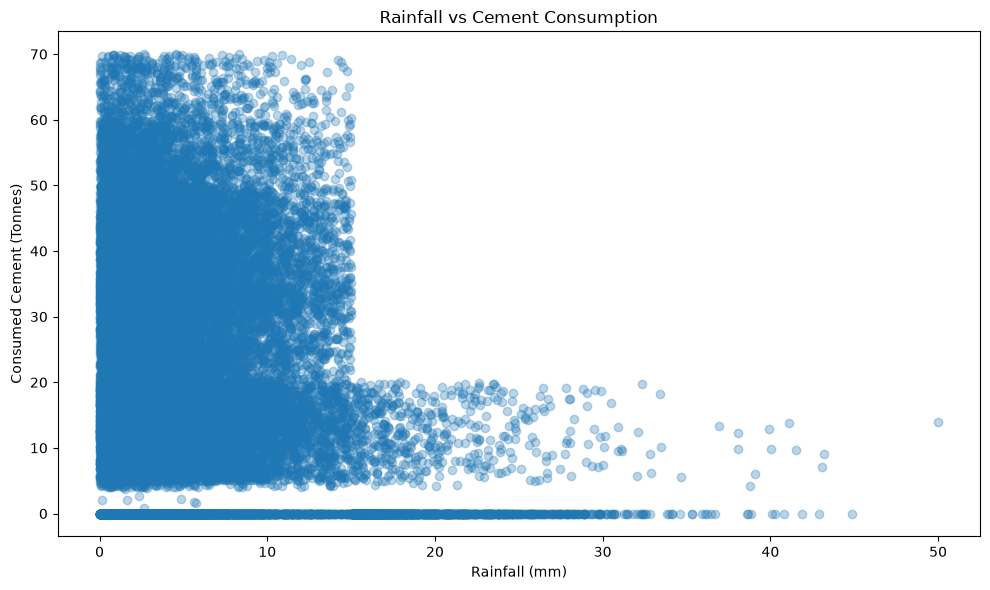

In [34]:
# Plot rainfall against actual cement consumption
# to investigate whether higher rainfall is associated
# with changes in cement demand.
plt.figure(figsize=(10, 6))

plt.scatter(
    df["rain_mm"],
    df["consumed_tonnes"],
    alpha=0.3
)

plt.title("Rainfall vs Cement Consumption")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Consumed Cement (Tonnes)")
plt.tight_layout()

plt.show()

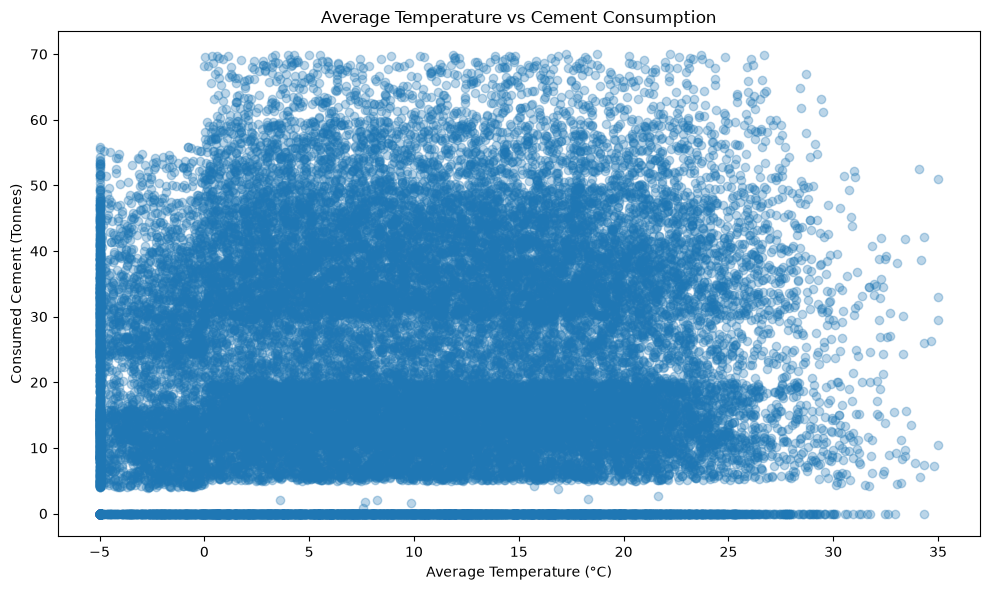

In [35]:
# Plot average temperature against actual cement consumption
# to investigate whether temperature is associated with demand.
plt.figure(figsize=(10, 6))

plt.scatter(
    df["avg_temp_c"],
    df["consumed_tonnes"],
    alpha=0.3
)

plt.title("Average Temperature vs Cement Consumption")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Consumed Cement (Tonnes)")
plt.tight_layout()

plt.show()

In [36]:
# Select numerical variables that are relevant to demand,
# inventory, deliveries, weather and operational performance.
correlation_columns = [
    "planned_pour_tonnes",
    "consumed_tonnes",
    "opening_inventory_tonnes",
    "deliveries_tonnes",
    "closing_inventory_tonnes",
    "rain_mm",
    "avg_temp_c",
    "silo_capacity",
    "available_inventory_tonnes",
    "unmet_demand_tonnes",
    "stockout_flag",
    "pour_fulfilment_rate"
]

# Calculate the Pearson correlation matrix.
correlation_matrix = (
    df[correlation_columns]
    .corr()
    .round(2)
)

# Display the correlation matrix.
correlation_matrix

,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,available_inventory_tonnes,unmet_demand_tonnes,stockout_flag,pour_fulfilment_rate
planned_pour_tonnes,1.00,0.78,-0.52,-0.01,-0.52,0.00,0.00,-0.03,-0.52,0.52,0.48,-0.41
consumed_tonnes,0.78,1.00,-0.39,0.18,-0.39,-0.18,0.04,-0.02,-0.39,-0.13,0.19,0.31
opening_inventory_tonnes,-0.52,-0.39,1.00,0.03,1.00,0.00,-0.07,0.02,1.00,-0.29,-0.31,0.29
deliveries_tonnes,-0.01,0.18,0.03,1.00,0.03,-0.01,-0.01,-0.01,0.03,-0.25,-0.16,0.29
closing_inventory_tonnes,-0.52,-0.39,1.00,0.03,1.00,0.00,-0.07,0.02,1.00,-0.29,-0.31,0.29
rain_mm,0.00,-0.18,0.00,-0.01,0.00,1.00,0.01,0.00,0.00,0.25,-0.09,-0.29
avg_temp_c,0.00,0.04,-0.07,-0.01,-0.07,0.01,1.00,-0.00,-0.07,-0.04,0.16,0.09
silo_capacity,-0.03,-0.02,0.02,-0.01,0.02,0.00,-0.00,1.00,0.02,-0.02,-0.03,0.02
available_inventory_tonnes,-0.52,-0.39,1.00,0.03,1.00,0.00,-0.07,0.02,1.00,-0.29,-0.31,0.29
unmet_demand_tonnes,0.52,-0.13,-0.29,-0.25,-0.29,0.25,-0.04,-0.02,-0.29,1.00,0.51,-0.96


In [37]:
# Extract correlations between actual cement consumption
# and the other numerical variables.
consumption_correlations = (
    correlation_matrix["consumed_tonnes"]
    .drop("consumed_tonnes")
    .sort_values(ascending=False)
)

# Display the correlations from strongest positive
# to strongest negative.
consumption_correlations

planned_pour_tonnes           0.78
pour_fulfilment_rate          0.31
stockout_flag                 0.19
deliveries_tonnes             0.18
avg_temp_c                    0.04
silo_capacity                -0.02
unmet_demand_tonnes          -0.13
rain_mm                      -0.18
opening_inventory_tonnes     -0.39
closing_inventory_tonnes     -0.39
available_inventory_tonnes   -0.39
Name: consumed_tonnes, dtype: float64

In [38]:
# Examine which numerical variables are most strongly
# associated with unmet cement demand.
unmet_demand_correlations = (
    correlation_matrix["unmet_demand_tonnes"]
    .drop("unmet_demand_tonnes")
    .sort_values(ascending=False)
)

unmet_demand_correlations

planned_pour_tonnes           0.52
stockout_flag                 0.51
rain_mm                       0.25
silo_capacity                -0.02
avg_temp_c                   -0.04
consumed_tonnes              -0.13
deliveries_tonnes            -0.25
opening_inventory_tonnes     -0.29
closing_inventory_tonnes     -0.29
available_inventory_tonnes   -0.29
pour_fulfilment_rate         -0.96
Name: unmet_demand_tonnes, dtype: float64